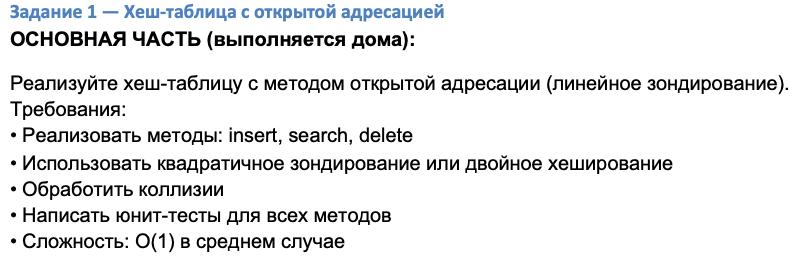

In [1]:
from IPython.display import Image
Image(filename='/Users/marusiavolodina/Desktop/физтех/алгосы/indiv_task.jpeg', width=800)

Перед тем как приступить к непосредственной реализации, определим понятие простого числа. Зачем это в нашей задаче: размер массива всегда выбираем простым по причине того, что в формулах Open Adressing присутвует ```% size``` — если size составное, для некоторых ключей формула зацикливается на определенных ячейках, переставая перебирать все, из-за чего повышается вероятность коллизий. Если же size простое — такого не происходит.

In [2]:
def is_prime(n):                          #n - простое или нет?
    if n < 2:                              
        return False
    if n % 2 == 0:                       
        return n == 2
    i = 3
    while i * i <= n:                     #перебираем нечётные делители до sqrt(n)
        if n % i == 0:                    #если делитель нашелся - n составное
            return False
        i += 2
    return True                           #делитель не нашелся - n простое


def next_prime(n):                        #поиск ближайшего к n простого числа >= n
    m = n
    while not is_prime(m):
        m += 1
    return m

# Разрешение коллизий в хэш-таблицах открытой адрессацией (open addressing)

Коллизия — один key для нескольких buckets

### Open adressing
1. Линейное зондирование: ```((hash + i) % size)``` — образует кластеры: занятые слоты слипаются, поиск незанятого места получается не очень качественный
2. Квадратичное зондирование: ```(hash + sqrti) % size```
3. Двойное хеширование: ```(hash1 + i * hash2) % size```
 
В отличие от 1, подходы 2 и 3 более равномерно раскидывают элементы.

Для реализации я выбрала квадратичное зондирование. 

### HashTable

Введем понятие **класса функций** - это способ упаковки данных и функций, работающих с этими данными, в один объект, чтобы условно не таскать все переменные за собой при каждом новом вызове функции.

Так как задание заключается в том, чтобы реализовать хэш-таблицу, так сказать, from scratch, понятно что никаких готовых set и dict мы не можем использовать. Соответственно, надо самостоятельно определить класс функций,  который описывает как в принципе устроена хэш-таблица. Я ввела класс HashTable, на выходе он должен уметь осуществлять insert, search, delete.

**План работы** заключается в том, чтобы а) собственно создать работающий класс HashTable б) проверить, что он реально работающий. 

### Проверка
1. Просто вручную создадим таблицу, впишем несколько элементов и и посмотрим на результат. Это проверка "на глаз", чтобы, при наличии, убрать какие-то глобальные ошибки
2. Формальная проверка через **unittest** - встроенный в Python модуль для автоматического тестирования. 

## Мини-теория и обозначение, что мы вообще хотим достичь и каким образом
1. В Open adressing и ключ, и значение хранятся в одной ячейке. Почему так: концептуально наша цель - прийти в ячейку по индексу; но изначально мы не знаем, подходящий или нет тот ключ, который там лежит - в ячейку из-за коллизий мог попасть и какой-то другой элемент. Вывод: если будем хранить ключ и значение рядом, то появляется возможность проверить ключ при поиске.
2. **Про tombstone**. У ячейки должно быть три различимых состояния: пусто изначально (None), занято ([key, value]), и пусто после удаления (tombstone). Зачем нужен последний: при удалении элемента мы физически убираем его из ячейки, но другие элементы могли попасть в свои ячейки позже, из-за коллизии с удаленным, то есть путь их зондирования проходит через "опустошенную" ячейку. Выходит, нужен отдельный маркер, чтобы программа не остананвливалась на пустой ячейке такого типа.
3. ```__init__``` - дандер-метод в Python, запускается в момент создания объекта.

Синтаксис:

In [3]:
def __init__(self, initial_size=11):
    self.something = ...

А что за selfы должны лежать в ```__init__```?

In [4]:
class HashTable:
    def __init__(self, initial_size=13):
        self.size = next_prime(initial_size)  #размер массива - обязательно простое число
        self.count = 0                        #счётчик физически существующих элементов - изначально таблица пустая
        self.slots = [None] * self.size       #массив ячеек - все изначально пустые
        self.tombstone = object()             #tombstone-маркер

In [5]:
t = HashTable(initial_size=10)
print(t.size)
print(t.slots)
print(t.count)

11
[None, None, None, None, None, None, None, None, None, None, None]
0


Мы увидели , что ```__init__``` работает, переходим к ```_hash```.

4. ```_hash``` - превращает ключ(строку) в число. ```_hash(key)``` должна возвращать число, лежащее в диапазоне от 0 до n-1, если n - длина ```self.size```. Как это гарантировать: взять результат по модулю self.size ```%```.

In [6]:
def _hash(self, key):
    h = 0                                     #накопитель
    for ch in key:                            #идём по символам строки key 
        h = (h * 31 + ord(ch)) % self.size    #домножаем накопленное на 31, прибавляем код символа, берём остаток
    return h                                  #возвращаем хэш

### Формула квадратичного зондирования

In [7]:
def q_probe(self, key):
    h = self._hash(key)                  #хэш ключа
    for i in range(self.size):         
        yield (h + i * i) % self.size    #формула квадратичного зондирования, 

#yield - это генератор, он пишется вместо return, возвращая индексы по одному и фиксируя на каком шаге он остановился

Функцию, которая будет использоваться во всех методах трёх ```insert```, ```search```, ```delete``` определили. Переходим к их реализации.

### search
Обозначим, что происходит при каждом возможном значении ячейки
1. ```None``` - остановка, возвращаем ```None```
2. ```self.tombstone``` - идём на следующий индекс
3. ```[key, value]```, но key не подходит к value - произошла коллизия, идём на следующий индекс
4. ```[key, value]```, key подходит к value - нашли, что искали, остановка, возвращаем ```value```

In [8]:
def search(self, key):
    for cell in self.q_probe(key):                  #перебор индексов ячеек, cell - посчитанный q_probe индекс
        slot = self.slots[cell]                     #смотрим что лежит в ячейке

        if slot is None:                       
            return None                          

        if slot is self.tombstone:              
            continue                              

        if slot[0] == key:                       
            return slot[1]                          

        #случай 3 (slot[0] != key) - ничего не делаем, цикл сам переходит к следующему индексу

    return None                                   #прошло self.size попыток, ключа нет

### insert
Снова проговорим, что делаем при каком значении ячейки
1. ```None``` - нигде раньше в цепочке этот ключ не встретился, остановка, кладем новый элемент
2. ```self.tombstone``` - запоминаем эту ячейку, но сразу туда не кладем - подходящий ключ может оказаться дальше. идем по цепочке, проверяем, если там нет, возвращаемся и кладем в tombstone
3. ```[key, value]```, но key не совпадает - коллизия, не наш ключ, идем дальше
5. ```[key, value]```, key совпадает - перезаписываем значение в этой ячейке

In [9]:
def insert(self, key, value):
    first_tombstone = None                          #на всякий случай запоминаем первый попавшийся tombstone
    
    if (self.count + 1) / self.size > 0.7:          #подробно см. ниже
        self._resize()
    
    for cell in self.q_probe(key):
        slot = self.slots[cell]

        if slot is None:                                                        
            target = first_tombstone if first_tombstone is not None else cell   
            self.slots[target] = [key, value]
            self.count += 1
            return

        if slot is self.tombstone:               
            if first_tombstone is None:            #запоминаем только первый tombstone
                first_tombstone = cell
            continue

        if slot[0] == key:                        
            slot[1] = value
            return

        # случай 3 - не наш ключ - ничего не делаем, идём дальше

### delete
1. ```None``` - удалять нечего, раз дошли до сюда, то ключа в таблице нет, остановка, выводим ```None```
2. ```self.tombstone``` - идем дальше по цепочке, проверяем, возможно там есть
3. ```[key, value]```, но key не совпадает - коллизия, не наш ключ, идем дальше, его не трогаем
5. ```[key, value]```, key совпадает - удаляем, но, чтобы случайно не потерять нужную информацию, ставим маркер ```self.tombstone```(не стираем до ```None```). При этом, перед тек как заменить ячейку на tombstone, нужно в отдельную переменную записать value из нее
   

In [10]:
def delete(self, key):
    for cell in self.q_probe(key):
        slot = self.slots[cell]

        if slot is None:
            return None

        if slot is self.tombstone:
            continue

        if slot[0] == key:
            previous_value = slot[1]
            self.slots[cell] = self.tombstone
            self.count -= 1
            return previous_value
    return None

Теперь поговорим о том, в каких случаях нам может понадобиться  увеличить хэш-таблицу, и каким образом это реализовывать.

### _resize
Допустим, у нас есть таблица размером ```self.size = n```, а мы уже вставили n-1 элемент и хотим еще. В таком случае поиск свободного места будет занимать слишком долгое время, и производительность O(1) в общем случае теряется. Как решать такую проблему? Не допускать того, чтобы степень заполненности таблицы(load factor, $alpha$) превышало ~ 0.7. Когда $alpha$ приближается к этому порогу, таблицу увеличивают. ```Resize``` "стоит" O(n), но так как случается редко, на общую(аммортизированную) сложность влияет не сильно и она остается около O(1).

Интуитивно понятно, что в купе с методами, рассмотренными выше, ```resize``` имеет смысл применять только для ```insert```.

Важно сказать, что с увеличением таблицы появляется необходимость "перехэшировать" уже существующиеся элементы. Почему так: ```_hash(key) = ... % self.size``` - выражение для хэш-ключа явно зависит от размера таблицы. Если этого не сделать, зондирование пойдет не с того места в массиве и элемент не найдется.

In [11]:
def _resize(self):
    old_slots = self.slots                     #сохраняем старый массив 
    self.size = next_prime(self.size * 2)
    self.slots = [None] * self.size
    self.count = 0
    
    for slot in old_slots:
        if slot is not None and slot is not self.tombstone:
            self.insert(slot[0], slot[1])

Теперь понятно, что ```_resize``` нужно добавить в ```insert```.

Все обозначенные функции сложим в HashTable:

In [12]:
class HashTable:
    def __init__(self, initial_size=13):
        self.size = next_prime(initial_size)
        self.count = 0
        self.slots = [None] * self.size
        self.tombstone = object()

    def _hash(self, key):
        h = 0
        for ch in key:
            h = (h * 31 + ord(ch)) % self.size
        return h

    def q_probe(self, key):
        h = self._hash(key)
        for i in range(self.size):
            yield (h + i * i) % self.size

    def search(self, key):
        for cell in self.q_probe(key):
            slot = self.slots[cell]

            if slot is None:
                return None

            if slot is self.tombstone:
                continue

            if slot[0] == key:
                return slot[1]

        return None

    def insert(self, key, value):
        if (self.count + 1) / self.size > 0.7:
            self._resize()

        first_tombstone = None
        for cell in self.q_probe(key):
            slot = self.slots[cell]

            if slot is None:
                target = first_tombstone if first_tombstone is not None else cell
                self.slots[target] = [key, value]
                self.count += 1
                return

            if slot is self.tombstone:
                if first_tombstone is None:
                    first_tombstone = cell
                continue

            if slot[0] == key:
                slot[1] = value
                return

    def delete(self, key):
        for cell in self.q_probe(key):
            slot = self.slots[cell]

            if slot is None:
                return None

            if slot is self.tombstone:
                continue

            if slot[0] == key:
                previous_value = slot[1]
                self.slots[cell] = self.tombstone
                self.count -= 1
                return previous_value

        return None

    def _resize(self):
        old_slots = self.slots
        self.size = next_prime(self.size * 2)
        self.slots = [None] * self.size
        self.count = 0

        for slot in old_slots:
            if slot is not None and slot is not self.tombstone:
                self.insert(slot[0], slot[1])

## Юнит тесты
На данном этапе для каждого метода нужно понять, что где может сломаться. Для этого необходимо придумать несколько тест-функций.

In [13]:
import unittest

### search: что может сломаться?
1. ```search``` не находит элемент, который на самом деле есть (false negative)
2. ```search``` "находит" элемент, которого реально нет (false positive)
3. ```search``` останавливается на tombstone вместо того, чтобы идти дальше
4. ```search``` в пустой таблице дает ошибку вместо None

In [14]:
class TestSearch(unittest.TestCase):
    
    def setUp(self):
        self.table = HashTable(initial_size=11)
    
    def test_s_1(self):
        self.table.insert("key", 1)
        self.assertEqual(self.table.search("key"), 1)
 
    def test_s_2(self):
        self.assertIsNone(self.table.search("not here"))
 
    def test_s_3(self):
        empty = HashTable(initial_size=11)
        self.assertIsNone(empty.search("anything"))
 
    def test_s_4(self):
        table = HashTable(initial_size=5)
        table.insert("a", 1)
        table.insert("f", 2)                     #'f' уходит на соседнюю ячейку из-за коллизии с 'a'
        table.delete("a")                        #на месте 'a' ставим tombstone 
        self.assertEqual(table.search("f"), 2)   # search обязан пройти дальше tombstone, а не остановиться

### insert: что может сломаться?
1. ```insert``` создаёт дубликат ключа вместо перезаписи значения (два элемента с одним и тем же ключом одновременно)
2. ```insert``` стирает не свой существующий элемент при коллизии вместо поиска следующей свободной ячейки
3. ```insert``` неправильно использует зафиксированный tombstone — кладёт туда раньше времени, до того как убедился, что ключа нет дальше по цепочке
4. ```insert``` не увеличивает count при реальной вставке нового элемента (или увеличивает при перезаписи существующего — это тоже ошибка)

In [15]:
class TestInsert(unittest.TestCase):

    def setUp(self):
        self.table = HashTable(initial_size=11)

    def test_i_1(self):
        self.table.insert("key", 1)
        self.assertEqual(self.table.count, 1)

    def test_i_2(self):
        self.table.insert("key", 1)
        self.table.insert("key", 999)          #тот же ключ - нужно перезаписать
        self.assertEqual(self.table.search("key"), 999)
        self.assertEqual(self.table.count, 1)    #count не должен вырасти

    def test_i_3(self):
        table = HashTable(initial_size=5)
        table.insert("a", 1)
        table.insert("f", 2)                     #'f' должен уйти на соседнюю ячейку из-за коллизии с 'a'
        self.assertEqual(table.search("a"), 1)   #'a' должен остаться
        self.assertEqual(table.search("f"), 2)

    def test_i_4(self):
        table = HashTable(initial_size=5)
        table.insert("a", 1)
        table.delete("a")                 #освобождаем ячейку - там теперь tombstone
        table.insert("newkey", 100)       #новая вставка может занять этот tombstone
        self.assertEqual(table.search("newkey"), 100)

### delete: что может сломаться?
1. ```delete``` не находит существующий ключ, ошибка в логике перебора ```q_probe```
2. ```delete``` заменяет ячейку на ```None``` вместо  ```tombstone``` — ломает search для других элементов той же цепочки коллизии
3. ```delete``` не уменьшает ```count``` после удаления
4. ```delete``` возвращает неверное значение вместо реально удалённого

In [16]:
class TestDelete(unittest.TestCase):

    def setUp(self):
        self.table = HashTable(initial_size=11)

    def test_d_1(self):
        self.table.insert("key", 1)
        self.assertEqual(self.table.delete("key"), 1)

    def test_d_2(self):
        self.table.insert("key", 1)
        self.table.delete("key")
        self.assertIsNone(self.table.search("key"))

    def test_d_3(self):
        self.assertIsNone(self.table.delete("not here"))

    def test_d_4(self):
        self.table.insert("key", 1)
        self.table.delete("key")
        self.assertEqual(self.table.count, 0)

    def test_d_5(self):
        table = HashTable(initial_size=5)
        table.insert("a", 1)
        table.insert("f", 2)                     #коллизия с 'a'
        table.delete("a")
        self.assertEqual(table.search("f"), 2)   #'f' должен находиться

### _resize: что может сломаться?
1. после ```resize``` элементы "теряются" — неправильный перенос старых данных в новый массив
2. после ```resize``` $alpha$ всё равно остаётся выше порога 0.7 (```resize``` сработал, но недостаточно)
3. ```resize``` не запускается вовремя, и ```insert``` зависает на переполненной таблице

In [17]:
class TestResize(unittest.TestCase):

    def test_r_1(self):
        table = HashTable(initial_size=3)          #маленький старт - resize сработает быстро
        keys = [f"key{i}" for i in range(30)]
        for i, key in enumerate(keys):
            table.insert(key, i)
        for i, key in enumerate(keys):
            self.assertEqual(table.search(key), i)  #все элементы должны найтись после нескольких resize подряд

    def test_r_2(self):
        table = HashTable(initial_size=3)
        for i in range(30):
            table.insert(f"key{i}", i)
        self.assertLessEqual(table.count / table.size, 0.7)

Проверяем результат работы тестов:

In [18]:
unittest.main(argv=[''], exit=False)

...............
----------------------------------------------------------------------
Ran 15 tests in 0.003s

OK
